In [1]:
#Import thư viện
import re
import regex as re2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import sparse
from IPython.display import display

#Cấu hình style cho biểu đồ
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

#Tải dữ liệu bảng CSV từ github
!mkdir data
!wget https://raw.githubusercontent.com/levandinhhuy/mlAssignments/refs/heads/main/Assignment2/data/arxiv34k6L.csv -O data/arxiv34k6L.csv
raw_data = pd.read_csv("data/arxiv34k6L.csv")
raw_data.replace({r'â€‰':'', r'\u2009': ''}, regex=True, inplace=True) #Làm sạch dữ liệu

# #Kiểm tra số lượng mẫu và thuộc tính gốc của dữ liệu
print("Số lượng mẫu có trong dataset là:", raw_data.shape[0])
print("Số lượng thuộc tính có trong dataset là:", raw_data.shape[1])
print("Các thuộc tính có trong dataset là:", raw_data.columns)

#In thử 10 dòng đầu
raw_data.head(10)

--2026-03-14 14:34:15--  https://raw.githubusercontent.com/levandinhhuy/mlAssignments/refs/heads/main/Assignment2/data/arxiv34k6L.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44011485 (42M) [text/plain]
Saving to: ‘data/arxiv34k6L.csv’

data/arxiv34k6L.csv 100%[===================>]  41.97M  --.-KB/s    in 0.1s    

2026-03-14 14:34:16 (317 MB/s) - ‘data/arxiv34k6L.csv’ saved [44011485/44011485]

Số lượng mẫu có trong dataset là: 34068
Số lượng thuộc tính có trong dataset là: 2
Các thuộc tính có trong dataset là: Index(['Abstracts', 'categories'], dtype='object')


,Abstracts,categories
0,Reusing features in deep networks through dens...,['cs.CV']
1,Visual defect detection (VDD) for high-mix low...,['cs.CV']
2,Dense object detectors rely on the sliding-win...,['cs.CV']
3,The state-of-the-art object detection and imag...,['cs.CV']
4,This paper explores self-supervised learning o...,['cs.CV']
5,We present a conceptually simple framework for...,['cs.CV']
6,Object detection in aerial images is an import...,['cs.CV']
7,"In this paper, we are concerned with the detec...",['cs.CV']
8,Visual salient object detection (SOD) aims at ...,['cs.CV']
9,Prior research on self-supervised learning has...,['cs.CV']


Abstracts     0
categories    0
dtype: int64
Duplicates: 6811
text_col: Abstracts label_col: categories


,count
categories,
['cs.LG'],8140
['cs.CV'],8051
"['cs.LG', 'cs.AI']",6134
"['cs.LG', 'stat.ML']",4266
"['cs.CV', 'cs.AI']",3818


Average labels per sample: 1.5247446283902784
Average labels per sample: 1.5247446283902784
count    34068.000000
mean       179.023893
std         43.696691
min          5.000000
25%        149.000000
50%        178.000000
75%        208.000000
max        349.000000
Name: Abstracts, dtype: float64


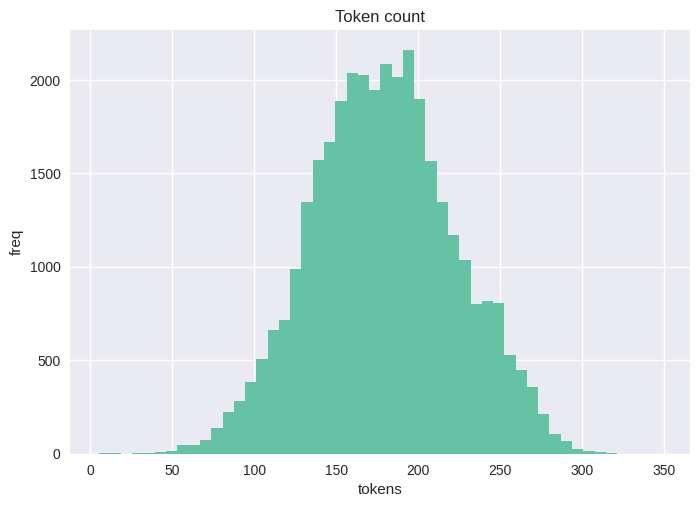

Max length:  253
Vocab_limit:  30000


In [2]:
import ast

# Kiểm tra dữ liệu null và trùng lặp
print(raw_data.isna().sum().sort_values(ascending=False).head())
print("Duplicates:", raw_data.duplicated().sum())

# Xác định cột văn bản và cột nhãn
obj_cols = [c for c in raw_data.columns if raw_data[c].dtype=='object']
text_col = max(obj_cols, key=lambda c: raw_data[c].astype(str).str.len().mean())
label_col = [c for c in raw_data.columns if c != text_col][0]  # dataset có 2 cột

print("text_col:", text_col, "label_col:", label_col)

# Thống kê phân phối nhãn
vc = raw_data[label_col].value_counts().head(5)
label_distribution = pd.DataFrame(vc)
label_distribution.columns = ['count']
display(label_distribution)

# Kiểm tra multi-label

labels_per_sample = raw_data[label_col].str.split().apply(len)

print("Average labels per sample:", labels_per_sample.mean())

print("Average labels per sample:", labels_per_sample.mean())

# Thống kê độ dài văn bản
lens = raw_data[text_col].astype(str).str.split().map(len)
print(lens.describe())
plt.figure(); lens.hist(bins=50); plt.title('Token count'); plt.xlabel('tokens'); plt.ylabel('freq'); plt.show()

# Đề xuất max_len và vocab_limit
max_len = int(np.percentile(lens, 95))  # gợi ý
vocab_limit = 30000
print("Max length: ", max_len)
print("Vocab_limit: ", vocab_limit)

In [3]:
import re
import pandas as pd

# Lấy toàn bộ dữ liệu
all_text = raw_data[text_col]

# Regex: cho phép một số ký tự phổ biến trong paper
pattern = re.compile(r"[^A-Za-z0-9\s\-\.\,\(\)\[\]\+\=\%]")

# Dòng chứa ký tự lạ
mask = all_text.str.contains(pattern, regex=True)

# Thống kê
count_special = mask.sum()
total = len(all_text)

print(f"Số dòng chứa ký tự lạ: {count_special}/{total} ({count_special/total:.2%})")

# Ví dụ
print("\nVí dụ:")
print(all_text[mask].sample(min(10, count_special), random_state=42).tolist())

# kiểm tra thêm ký tự LaTeX
from collections import Counter
special_chars = Counter()
for text in all_text:
    chars = re.findall(r"[^A-Za-z0-9\s]", str(text))
    special_chars.update(chars)

print(special_chars.most_common(20))

Số dòng chứa ký tự lạ: 19915/34068 (58.46%)

Ví dụ:
['Object detection is a well-known problem in computer vision. Despite this,\nits usage and pervasiveness in the traditional Indian food dishes has been\nlimited. Particularly, recognizing Indian food dishes present in a single photo\nis challenging due to three reasons: 1. Lack of annotated Indian food datasets\n2. Non-distinct boundaries between the dishes 3. High intra-class variation. We\nsolve these issues by providing a comprehensively labelled Indian food dataset-\nIndianFood10, which contains 10 food classes that appear frequently in a staple\nIndian meal and using transfer learning with YOLOv4 object detector model. Our\nmodel is able to achieve an overall mAP score of 91.8% and f1-score of 0.90 for\nour 10 class dataset. We also provide an extension of our 10 class dataset-\nIndianFood20, which contains 10 more traditional Indian food classes.', 'The self-attention mechanism in the transformer architecture is capable of\ncap

**Nhận xét về dữ liệu**

*Tính sạch của dữ liệu*

- Không có giá trị bị thiếu (NaN) trong cả hai cột.
- Dataset có **6811** dòng trùng lặp.

-> Dataset không có dữ liệu thiếu, tuy nhiên cần loại bỏ dữ liệu trùng lặp để tránh ảnh hưởng đến quá trình huấn luyện mô hình.

*Cột dữ liệu*
  - Abstracts: cột chứa văn bản (tóm tắt nội dung bài báo khoa học).
  - categories: cột nhãn phân loại lĩnh vực nghiên cứu.

*Phân phối nhãn*

5 nhóm nhãn xuất hiện nhiều nhất:

- ['cs.LG']: 8,140 mẫu (≈ 23.89%)

- ['cs.CV']: 8,051 mẫu (≈ 23.63%)

- ['cs.LG', 'cs.AI']: 6,134 mẫu (≈ 18.01%)

- ['cs.LG', 'stat.ML']: 4,266 mẫu (≈ 12.52%)

- ['cs.CV', 'cs.AI']: 3,818 mẫu (≈ 11.21%)

-> Các nhãn liên quan đến Machine Learning (cs.LG) và Computer Vision (cs.CV) chiếm phần lớn dữ liệu.

-> Một số mẫu có nhiều nhãn cùng lúc. Do đó, đây là bài toán **phân loại văn bản multi-label**.

*Độ dài văn bản*

- Trung bình: ~179 từ

- Median (50% dữ liệu): 178 từ

- 75% dữ liệu: ≤ 208 từ

- Văn bản ngắn nhất: 5 từ

- Văn bản dài nhất: 349 từ

-> Biểu đồ Histogram cho thấy phần lớn văn bản nằm trong khoảng 150–220 từ, chỉ một số ít văn bản rất ngắn hoặc rất dài.

*Tham số tiền xử lý đề xuất*

- max_len = ~250 (dựa trên percentile 95 của độ dài token) → đủ bao phủ 95% dữ liệu, tránh bị outlier kéo dài.

- vocab_limit = 30,000 → giới hạn từ vựng cho tokenizer, hạn chế ảnh hưởng của các từ hiếm, cân bằng giữa hiệu quả và tài nguyên.

In [4]:
!pip install scikit-multilearn
from sklearn.preprocessing import MultiLabelBinarizer
from skmultilearn.model_selection import iterative_train_test_split
import numpy as np
import ast

# Loại bỏ dòng trùng lặp (duplicate) trước khi split
before = len(raw_data)
raw_data = raw_data.drop_duplicates(subset=[text_col])
after = len(raw_data)

print("Removed duplicates:", before - after)
print("Remaining:", after)

# Convert label string -> list
labels = raw_data[label_col].apply(ast.literal_eval)


# Multi-label encode
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(labels)

# Features
X = raw_data[text_col].values.reshape(-1,1)

### Chia train 80%, test 10%, validation 10% ###
# Split test
X_train, y_train, X_test, y_test = iterative_train_test_split(
    X, Y, test_size=0.1
)

# Split validation
X_train, y_train, X_val, y_val = iterative_train_test_split(
    X_train, y_train, test_size=0.111
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 4.6 MB/s eta 0:00:00
Removed duplicates: 6812
Remaining: 27256
Train: 21808
Val: 2722
Test: 2726


In [5]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

class TextPreprocessor:

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def clean(self, text):

        text = str(text)

        # lowercase
        text = text.lower()

        # remove latex
        text = re.sub(r'\$.*?\$', ' ', text)

        # remove urls
        text = re.sub(r'http\S+|www\S+', ' ', text)

        # remove html
        text = re.sub(r'<.*?>', ' ', text)

        # remove punctuation & special characters
        text = re.sub(r'[^a-z\s]', ' ', text)

        # tokenize
        words = text.split()

        # remove stopwords + lemmatize
        words = [
            self.lemmatizer.lemmatize(w)
            for w in words
            if w not in self.stop_words
        ]

        return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [6]:
processor = TextPreprocessor()

# X_train, X_val, X_test hiện đang là numpy array từ iterative_train_test_split
# Chúng ta sẽ làm sạch và chuyển về list văn bản
X_train_final = [processor.clean(x[0]) for x in X_train]
X_val_final = [processor.clean(x[0]) for x in X_val]
X_test_final = [processor.clean(x[0]) for x in X_test]

print("RAW: ", X_train[0]) # Dòng đầu trước khi làm sạch
print("CLEAN: ", X_train_final[0]) # Dòng đầu sau khi làm sạch

RAW:  ['Visual defect detection (VDD) for high-mix low-volume production of\nnon-convex metal objects, such as high-pressure cylindrical piping joint parts\n(VDD-HPPPs), is challenging because subtle difference in domain (e.g., metal\nobjects, imaging device, viewpoints, lighting) significantly affects the\nspecular reflection characteristics of individual metal object types. In this\npaper, we address this issue by introducing a tailor-made VDD framework that\ncan be automatically adapted to a new domain. Specifically, we formulate this\nadaptation task as the problem of network architecture search (NAS) on a deep\nobject-detection network, in which the network architecture is searched via\nreinforcement learning. We demonstrate the effectiveness of the proposed\nframework using the VDD-HPPPs task as a factory case study. Experimental\nresults show that the proposed method achieved higher burr detection accuracy\ncompared with the baseline method for data with different training/test 

In [7]:
train_df = pd.DataFrame({
    "text": X_train_final,
    "labels": list(y_train)
})

val_df = pd.DataFrame({
    "text": X_val_final,
    "labels": list(y_val)
})

test_df = pd.DataFrame({
    "text": X_test_final,
    "labels": list(y_test)
})

train_df.to_csv("train_clean.csv", index=False)
val_df.to_csv("val_clean.csv", index=False)
test_df.to_csv("test_clean.csv", index=False)

## **Tiền xử lý dữ liệu**
Sau bước phân tích dữ liệu khám phá (EDA), dữ liệu văn bản được tiến hành tiền xử lý nhằm loại bỏ nhiễu và chuẩn hóa nội dung trước khi đưa vào mô hình học máy.

**1. Chuyển toàn bộ văn bản về chữ thường (Lowercase)**

Chuyển toàn bộ văn bản về chữ thường (Lowercase)
Tất cả ký tự trong văn bản được chuyển sang chữ thường để tránh việc cùng một từ nhưng khác kiểu chữ (ví dụ: "Learning" và "learning") bị xem là hai từ khác nhau.

**2. Loại bỏ biểu thức LaTeX**

Các biểu thức toán học trong văn bản được loại bỏ bằng biểu thức chính quy vì chúng không đóng góp nhiều vào nhiệm vụ phân loại chủ đề.

**3. Loại bỏ URL**

Các đường dẫn web (URL) được loại bỏ để tránh đưa các thông tin không liên quan vào mô hình.

**4. Loại bỏ thẻ HTML**

Các thẻ HTML (nếu có) được loại bỏ nhằm đảm bảo dữ liệu chỉ chứa nội dung văn bản.

**5. Loại bỏ dấu câu và ký tự đặc biệt**

Các ký tự không phải chữ cái được loại bỏ để giảm nhiễu trong dữ liệu.

**6. Tokenization**

Văn bản được tách thành các từ đơn (tokens) để phục vụ cho quá trình xử lý tiếp theo.

**7. Loại bỏ stopwords**

Các từ phổ biến nhưng ít mang ý nghĩa ngữ nghĩa như the, is, and, of,... được loại bỏ nhằm giảm kích thước từ vựng và tập trung vào các từ mang nhiều thông tin hơn.

**8. Lemmatization**

Các từ được đưa về dạng gốc của chúng nhằm giảm số lượng biến thể từ và giúp mô hình học hiệu quả hơn.

-> Sau khi hoàn tất quá trình tiền xử lý, dữ liệu văn bản được lưu lại thành các tập train, validation, và test để phục vụ cho các bước trích xuất đặc trưng và huấn luyện mô hình.

## **Trích Xuất Đặc Trưng**